# 02 — Tiền xử lý

Pipeline trích xuất giá/diện tích/phòng/tầng/mặt tiền, chuẩn hóa một phần Quận/Huyện/Phường/Xã và đánh dấu giá trị số không hợp lý.

**Nguyên tắc:** giá thiếu hoặc không đọc được bị loại; đặc trưng thiếu được giữ lại để impute bên trong pipeline huấn luyện, tránh rò rỉ thống kê từ tập kiểm tra.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "src" / "pipeline.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục dự án có src/pipeline.py")
sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
from src.pipeline import load_raw_data, clean_data, save_processed_data

raw = load_raw_data()
cleaned, report = clean_data(raw)
save_processed_data(cleaned, report)
display(report)
print(f"Dữ liệu đầy đủ đã lưu cục bộ: {len(cleaned):,} dòng")
print("Tệp làm sạch đầy đủ nằm trong data/processed/ và được loại khỏi Git.")
print("Bản demo công khai chỉ gồm 7 đặc trưng tổng quát, tối đa 5.000 dòng.")


,metric,value
0,raw_rows,51304
1,duplicate_rows_removed,0
2,missing_or_invalid_price_removed,172
3,impossible_numeric_values_set_missing,2778
4,price_outlier_flags_iqr_log,0
5,final_rows,51132


Dữ liệu đầy đủ đã lưu cục bộ: 51,132 dòng
Tệp làm sạch đầy đủ nằm trong data/processed/ và được loại khỏi Git.
Bản demo công khai chỉ gồm 7 đặc trưng tổng quát, tối đa 5.000 dòng.


## Kiểm tra kết quả làm sạch

Các giá trị thiếu trong đặc trưng không bị điền bằng toàn bộ dữ liệu tại bước này; model sẽ học median/category imputation chỉ từ tập train.

,Tỷ lệ thiếu
floors,0.780118
bedrooms,0.668251
frontage,0.322440
area_m2,0.038489
price_bil,0.000000
district,0.000000
property_type,0.000000


,count,mean,std,min,50%,90%,99%,max
price_bil,51132.0,32.648438,84.994946,0.1,7.0,69.0,455.000,1000.0
area_m2,49164.0,399.501183,733.596965,8.0,120.0,1046.0,4021.937,5000.0
bedrooms,16963.0,2.970229,2.389079,0.0,2.0,5.0,14.000,30.0
floors,11243.0,4.089789,5.309971,1.0,3.0,6.0,29.000,99.0
frontage,34645.0,12.042976,14.313427,0.5,6.1,26.0,80.000,100.0


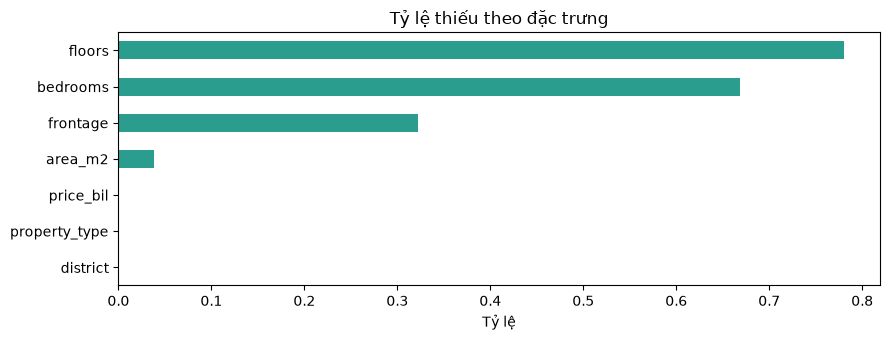

In [2]:
safe_columns = [
    "price_bil", "area_m2", "bedrooms", "floors", "frontage",
    "district", "property_type",
]
missing = cleaned[safe_columns].isna().mean().sort_values(ascending=False)
display(missing.rename("Tỷ lệ thiếu").to_frame())

numeric = cleaned[["price_bil", "area_m2", "bedrooms", "floors", "frontage"]]
display(numeric.describe(percentiles=[.5, .9, .99]).T)

figure, axis = plt.subplots(figsize=(9, 3.5))
missing.sort_values().plot.barh(ax=axis, color="#2A9D8F")
axis.set(title="Tỷ lệ thiếu theo đặc trưng", xlabel="Tỷ lệ", ylabel="")
figure.tight_layout()
plt.show()
